# Prepare Data For Modeling


### Import Libraries

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw


## Feature Engineering: Understanding Molecular Fingerprints

Before we can train a Machine Learning model, we must solve a fundamental problem: **Algorithms cannot understand raw text (SMILES strings) or 3D molecular drawings.** We need to translate our chemical structures into a mathematical format. 

To do this, we use **Molecular Fingerprints**.

### What is a Morgan Fingerprint?
In this project, we are using **Morgan Fingerprints** (also known as Circular Fingerprints), which is the industry standard for cheminformatics machine learning. 

Here is how the algorithm works:
1. **The Radius:** The algorithm looks at each atom in the molecule and expands outwards by a specific number of bonds (the "radius"). A radius of `2` means it looks at an atom and its neighbors up to 2 bonds away.
2. **Identifying Substructures:** It identifies all the unique structural fragments (functional groups, rings, bond types) within that radius.
3. **Hashing to an Array:** It maps these specific fragments to a fixed-length array of bits (usually 1024 or 2048 columns).

### How to interpret the Data
The output is a long row of `1`s and `0`s for every single molecule:
* `1` = The molecule **contains** the specific structural fragment assigned to that bit.
* `0` = The molecule **does not contain** that fragment.

### Why is this powerful?
By converting our 1,570 SMILES strings into a dataset of 1024 binary columns, we have created a rich, tabular dataset. Our Machine Learning model (like a Random Forest) can now mathematically learn which specific structural combinations (which `1`s and `0`s) are responsible for high or low Dopamine D2 receptor bioactivity!

In [3]:
df = pd.read_csv('..\Data\CSVs\Dopamine_D2_receptor_03_bioactivity_data_raw.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HP\AppData\Local\Temp\ipykernel_5420\2665887172.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('..\Data\CSVs\Dopamine_D2_receptor_03_bioactivity_data_raw.csv')


### An example of fingureprints

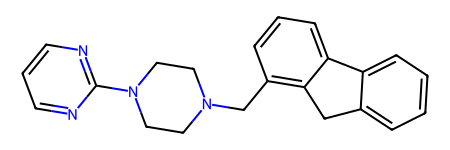

In [4]:
sample_smiles = df['canonical_smiles'].iloc[0]
sample_mol = Chem.MolFromSmiles(sample_smiles)
sample_mol

In [5]:
bit_info = {}

fp = AllChem.GetMorganFingerprintAsBitVect(sample_mol, radius=2, nBits=1024, bitInfo=bit_info)

# 4. Get a list of the bits (columns) that are "1" (active)
on_bits = list(bit_info.keys())
print(f"Total 'ON' bits for this molecule: {len(on_bits)}")

Total 'ON' bits for this molecule: 39


[16:20:50] DEPRECATION WARNING: please use MorganGenerator


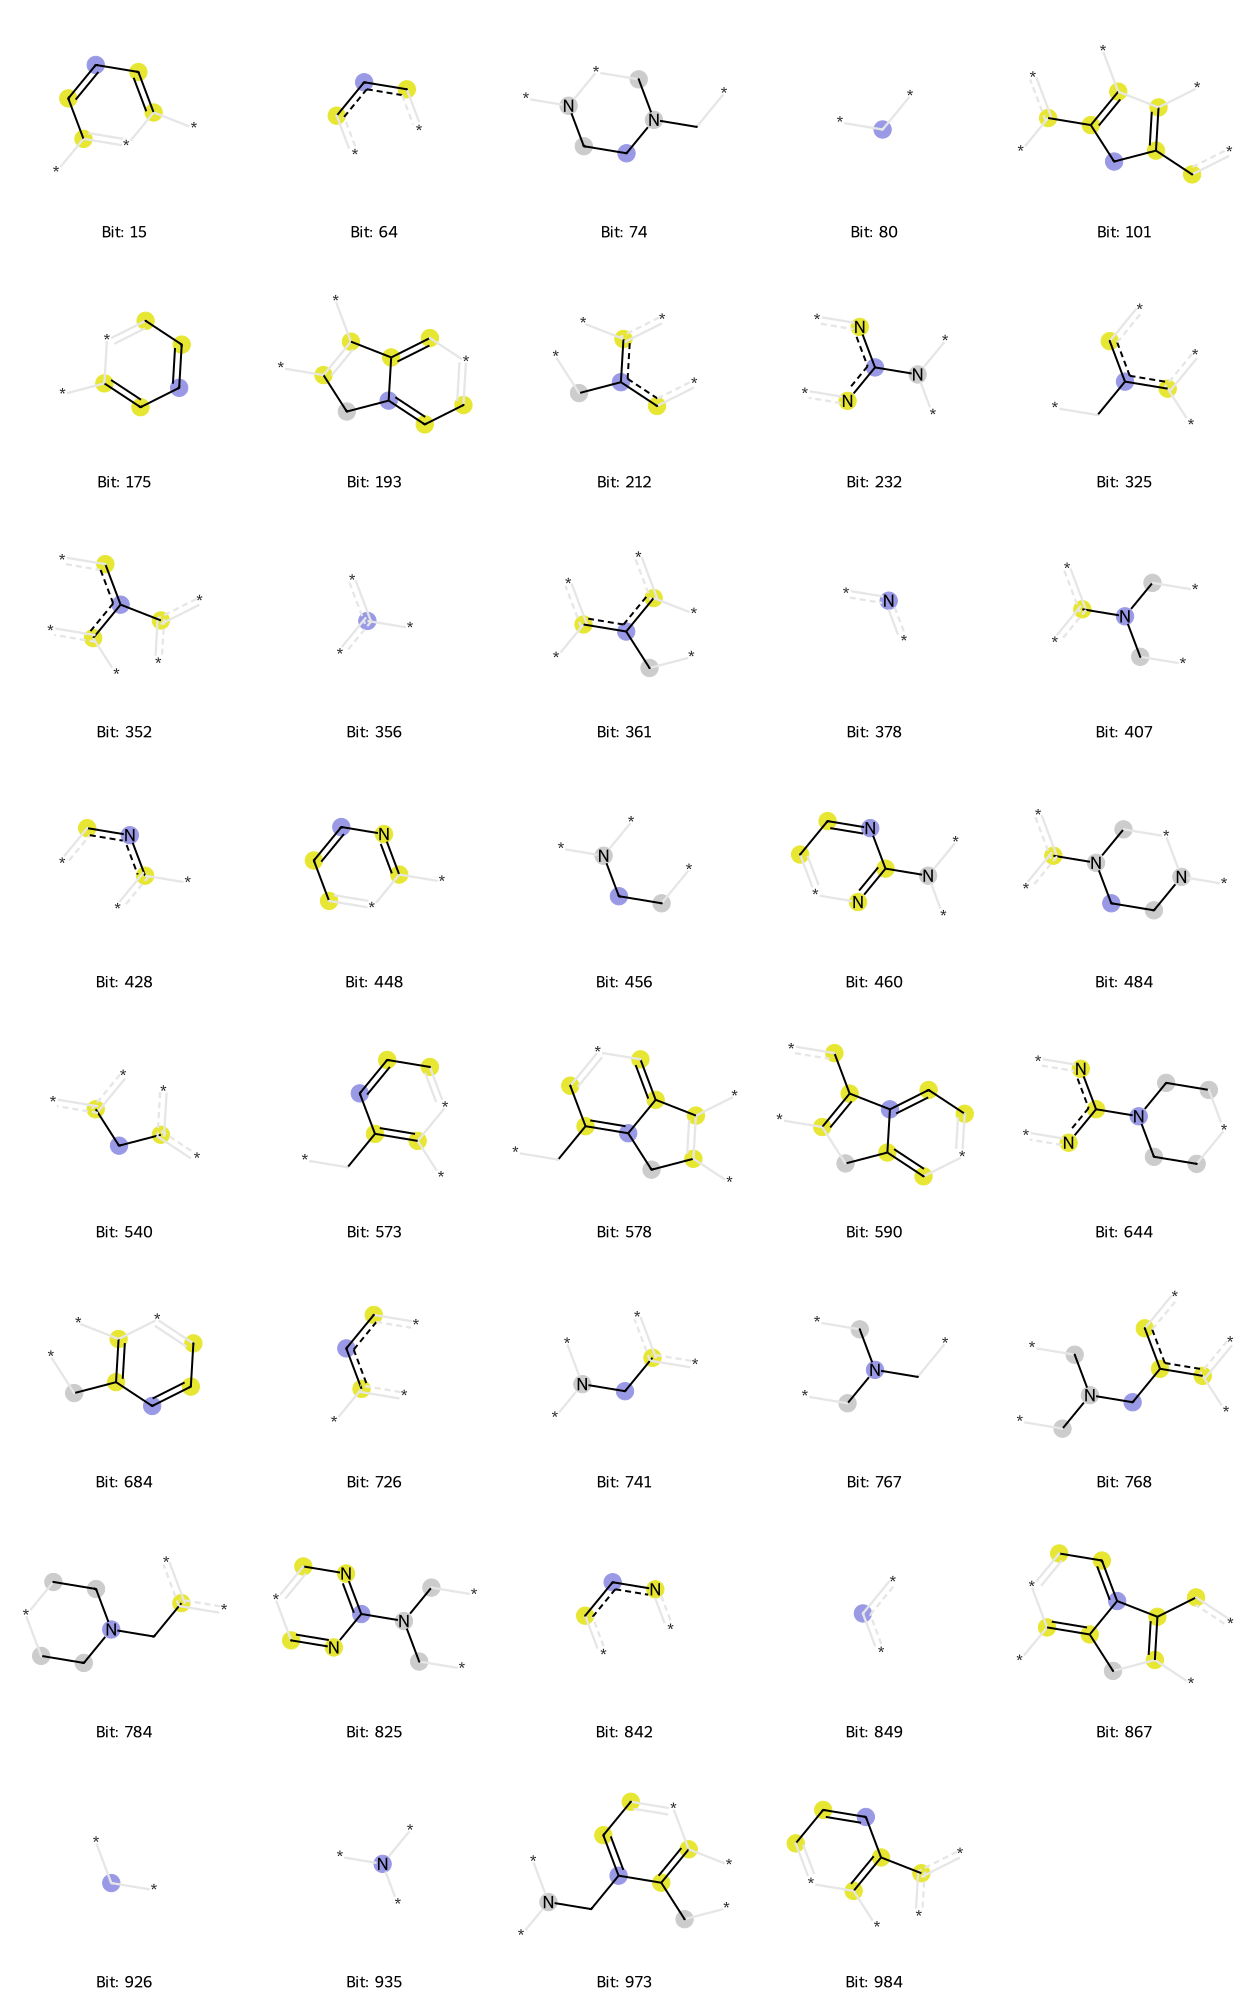

In [6]:

img = Draw.DrawMorganBits(
    [(sample_mol, bit, bit_info) for bit in on_bits],
    molsPerRow=5,
    legends=[f"Bit: {bit}" for bit in on_bits],
    subImgSize=(250, 250)
)
img

### As we see in the example if we combaine all of the 39 fragments we will get the molecule and the other bits will be 0s as they refer to another features

## Create The Data for modeling useing Morgan Fingerprint

In [7]:
df.columns

Index(['Unnamed: 0', 'molecule_chembl_id', 'canonical_smiles', 'MW', 'LogP',
       'NumHDonors', 'NumHAcceptors', 'pIC50'],
      dtype='object')

In [10]:
descriptor_list = df[['MW', 'LogP','NumHDonors', 'NumHAcceptors']]
descriptor_list

,MW,LogP,NumHDonors,NumHAcceptors
0,342.446,3.3700,0.0,4.0
1,360.461,3.4744,0.0,5.0
2,365.427,4.3490,0.0,3.0
3,360.461,3.4744,0.0,5.0
4,336.464,3.5273,0.0,5.0
...,...,...,...,...
1565,388.895,3.5755,0.0,4.0
1566,372.465,2.7866,0.0,5.0
1567,392.503,3.0707,1.0,4.0
1568,393.487,3.4034,1.0,4.0


In [13]:
def create_enhanced_dataset(df, descriptor_list):

    df.columns = [''.join(col) if isinstance(col, tuple) else col for col in df.columns]
    
    # 2. Fix if it contains tuples
    descriptor_list = [''.join(item) if isinstance(item, tuple) else item for item in descriptor_list]

    fps = []
    valid_indices = []
    
    for idx, smiles in enumerate(df['canonical_smiles']):
        mol = Chem.MolFromSmiles(str(smiles))
        if mol:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
            fps.append(list(fp))
            valid_indices.append(idx)
    
    # 1. Create Fingerprint DataFrame
    X_fp = pd.DataFrame(fps, columns=[f"Bit_{i}" for i in range(1024)])
    
    # 2. Grab Descriptors for valid indices only (Now the names will match!)
    X_desc = df.loc[valid_indices, descriptor_list].reset_index(drop=True)
    
    # 3. Grab Target Variable for valid indices only
    y = df.loc[valid_indices, 'pIC50'].reset_index(drop=True)
    
    # 4. Combine everything
    final_df = pd.concat([X_fp, X_desc, y], axis=1)
    
    return final_df

In [14]:
df_model = create_enhanced_dataset(df,descriptor_list)
df_model

[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerator
[16:43:47] DEPRECATION WARNING: please use MorganGenerat

,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,Bit_1019,Bit_1020,Bit_1021,Bit_1022,Bit_1023,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,342.446,3.3700,0.0,4.0,5.008774
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,360.461,3.4744,0.0,5.0,7.301030
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,365.427,4.3490,0.0,3.0,7.602060
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,360.461,3.4744,0.0,5.0,6.443697
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,336.464,3.5273,0.0,5.0,6.522879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1565,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,388.895,3.5755,0.0,4.0,5.045757
1566,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,372.465,2.7866,0.0,5.0,4.744727
1567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,392.503,3.0707,1.0,4.0,4.000000
1568,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,393.487,3.4034,1.0,4.0,6.160522


In [15]:
df_model.isna().sum()

Bit_0            0
Bit_1            0
Bit_2            0
Bit_3            0
Bit_4            0
                ..
MW               0
LogP             0
NumHDonors       0
NumHAcceptors    0
pIC50            0
Length: 1029, dtype: int64

### the encoding process done without errors

In [16]:
df_model.to_csv('..\Data\CSVs\Dopamine_D2_receptor_04_bioactivity_data_model.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HP\AppData\Local\Temp\ipykernel_5420\1117319686.py:1: SyntaxWarning: invalid escape sequence '\D'
  df_model.to_csv('..\Data\CSVs\Dopamine_D2_receptor_04_bioactivity_data_model.csv')
